In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import matplotlib.patches as mpatches

In [282]:
CSF_AD = pd.read_csv('data/CSF_AD.csv')
dx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')

In [283]:
print(CSF_AD.groupby(['RID','VISCODE']).size().sort_values(ascending=False).head())

RID   VISCODE
3     bl         1
4399  v11        1
      v03        1
      init       1
4396  v21        1
dtype: int64


In [284]:
def pretty_label(var_name):
    """
    Converts snake_case variable names into publication-ready labels.
    """

    # Remove common prefixes
    prefixes = ["adas_", "cdr_", "mmse_"]
    for p in prefixes:
        if var_name.startswith(p):
            var_name = var_name[len(p):]

    # Replace underscores with spaces
    var_name = var_name.replace("_", " ")

    # Capitalize words
    var_name = var_name.title()

    return f"{var_name} Score (ADAS-Cog)" 


In [308]:
def quadratic_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors with 95% CIs,
    and saves observed vs fitted trajectory plots.
    """

    formula = f"""
    {variable} ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_years:PT_AB_std
    + time_years:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:CARRIER
    + time_sq:edu_c
    + time_sq:age_c
    + time_sq:PT_AB_std
    + time_years:Sleep
    + time_years:UTI
    + time_years:CM
    + time_sq:Sleep
    + time_sq:UTI
    + time_sq:CM
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)

    # ── Confidence intervals ───────────────────────────────────────────────
    ci = model.conf_int()
    ci.columns = ["CI_lower", "CI_upper"]

    results = pd.DataFrame({
        "coef":     model.params,
        "CI_lower": ci["CI_lower"],
        "CI_upper": ci["CI_upper"],
        "pval":     model.pvalues
    })

    # ── Marginal and Conditional R² ───────────────────────────────────────
    var_fixed  = float(np.var(model.fittedvalues - model.resid))
    var_random = float(model.cov_re.iloc[0, 0])   # random intercept variance
    var_resid  = float(model.scale)                # residual variance

    r2_marginal    = var_fixed / (var_fixed + var_random + var_resid)
    r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

    # ── Print significant results ─────────────────────────────────────────
    sig_results = results[results["pval"] < 0.1].copy()
    sig_results["CI"] = (
        sig_results["CI_lower"].round(3).astype(str)
        + ", "
        + sig_results["CI_upper"].round(3).astype(str)
    )

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results[["coef", "CI_lower", "CI_upper", "pval"]].round(4))

    print(f"\nModel fit statistics:")
    print(f"  N patients:       {data['RID'].nunique()}")
    print(f"  N observations:   {len(data)}")
    print(f"  BIC:              {model.bic:.2f}")
    print(f"  Marginal R²:      {r2_marginal:.3f}")
    print(f"  Conditional R²:   {r2_conditional:.3f}")
    print(f"  Random intercept variance: {var_random:.3f}")
    print(f"  Residual variance:         {var_resid:.3f}")

    # ── Save to CSV ───────────────────────────────────────────────────────
    sig_results.to_csv(
        f"quadratic_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    # ── Plotting (unchanged) ──────────────────────────────────────────────
    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)
    template_row = data.iloc[[0]].copy()

    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():
        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue
        color = cmap(norm(person[color_var]))
        ax.plot(obs["time_years"], obs[variable],
                color=color, alpha=0.35, linewidth=1)
        ax.scatter(obs["time_years"], obs[variable],
                   color=color, alpha=0.5, s=10)

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]
    for _, person in person_df.iterrows():
        df_pred = pd.concat([template_row] * len(t_grid), ignore_index=True)
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]
        df_pred["time_years"] = t_grid
        df_pred["time_sq"]    = t_grid ** 2
        y_pred = model.predict(df_pred)
        color  = cmap(norm(person[color_var]))
        ax.plot(t_grid, y_pred, color=color, alpha=0.4, linewidth=1)

    # ── Reference curves: UTI vs No UTI
    for q, ls, lw, label in [
        (0, "--", 2.5, "No history of UTI or GI issues"),
        (1, "-",  2.5, "History of UTI or GI issues"),
    ]:
        ref = template_row.copy()
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()
        ref["UTI"] = q

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"]    = t_grid ** 2
        y_ref = model.predict(df_ref)

        ref_color = "#1b2a9e" if q == 0 else "#9e2d1b"
        ax.plot(t_grid, y_ref, linestyle=ls, linewidth=lw,
                color=ref_color, label=label)

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(f"{pretty_label(variable)}: Observed vs Model-fitted trajectories")
    fig.savefig(
        f"quadratic_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi, bbox_inches="tight"
    )
    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic, r2_marginal, r2_conditional, results




In [313]:

def linear_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
        {variable} ~ time_years
        + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + CM    
        + time_years:baseline_c 
        + time_years:HOMO
        + time_years:CARRIER 
        + time_years:PT_AB_std 
        + time_years:age_c 
        + time_years:PTGENDER 
        + time_years:edu_c 
        + time_years:Sleep
        + time_years:UTI
        + time_years:CM 
       
       
        """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.05]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"linear_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )

    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 2.5, "Low (P10)"),
        (0.5, "-",  2.5, "Median"),
        (0.9, "--", 2.5, "High (P90)")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)

       
        if q == 0.5:
            ref_color = "#1b9e77"  
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )

    fig.savefig(
        f"linear_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def compare_lin_quad(variable, data, name):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"linear_{name}"
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"quadratic_{name}"
    )[0]
    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")

### Compare how many individuals start and end as CN, MCI, AD:

=== First Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     337
MCI    492
AD     186
Name: count, dtype: int64
  Missing: 0

=== Last Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     278
MCI    340
AD     397
Name: count, dtype: int64
  Missing: 0

=== Transition counts (first → last) ===
last_dx      AD     CN    MCI
first_dx                     
AD        185.0    0.0    1.0
CN         22.0  260.0   55.0
MCI       190.0   18.0  284.0


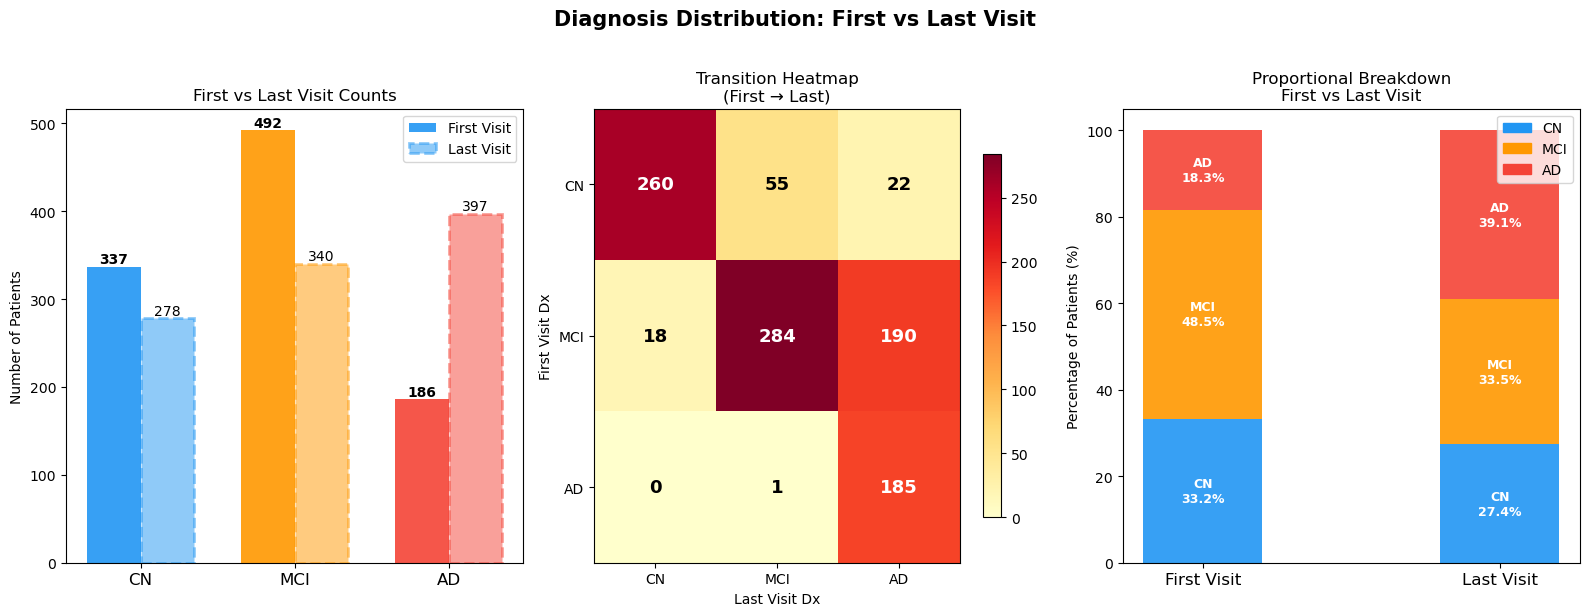

Plot saved.


In [292]:
# ── 1. Merge on RID + VISCODE ──────────────────────────────────────────────
merged = CSF_AD.merge(
    dx_df[['RID', 'VISCODE', 'DIAGNOSIS']],
    on=['RID', 'VISCODE'],
    how='left'
)

diag_map = {1: 'CN', 2: 'MCI', 3: 'AD'}
merged['DIAGNOSIS_LABEL'] = merged['DIAGNOSIS'].map(diag_map)

# ── 2. First & last visit per patient (by days_since_baseline}) ───────────────────
merged_sorted = merged.sort_values(['RID', 'days_since_entry'])

first_visit = merged_sorted.groupby('RID').first().reset_index()
last_visit  = merged_sorted.groupby('RID').last().reset_index()

first_counts = first_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)
last_counts  = last_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)

print("=== First Visit Diagnosis ===")
print(first_counts)
print(f"  Missing: {first_visit['DIAGNOSIS_LABEL'].isna().sum()}")

print("\n=== Last Visit Diagnosis ===")
print(last_counts)
print(f"  Missing: {last_visit['DIAGNOSIS_LABEL'].isna().sum()}")

# ── 3. Sankey-style transition counts ─────────────────────────────────────
transitions = merged_sorted.groupby('RID').agg(
    first_dx=('DIAGNOSIS_LABEL', 'first'),
    last_dx=('DIAGNOSIS_LABEL', 'last')
).reset_index()

transition_counts = transitions.groupby(['first_dx', 'last_dx']).size().reset_index(name='count')
print("\n=== Transition counts (first → last) ===")
print(transition_counts.pivot(index='first_dx', columns='last_dx', values='count').fillna(0))

# ── 4. Plot ────────────────────────────────────────────────────────────────
colors = {'CN': '#2196F3', 'MCI': '#FF9800', 'AD': '#F44336'}
categories = ['CN', 'MCI', 'AD']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Diagnosis Distribution: First vs Last Visit', fontsize=15, fontweight='bold', y=1.02)

# — Panel 1: Grouped bar chart —
ax1 = axes[0]
x = np.arange(len(categories))
w = 0.35
bars1 = ax1.bar(x - w/2, [first_counts[c] for c in categories], w,
                label='First Visit', color=[colors[c] for c in categories], alpha=0.9)
bars2 = ax1.bar(x + w/2, [last_counts[c] for c in categories],  w,
                label='Last Visit',  color=[colors[c] for c in categories], alpha=0.5,
                edgecolor=[colors[c] for c in categories], linewidth=2, linestyle='--')
ax1.set_xticks(x); ax1.set_xticklabels(categories, fontsize=12)
ax1.set_ylabel('Number of Patients'); ax1.set_title('First vs Last Visit Counts')
ax1.legend()
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# — Panel 2: Transition heatmap —
ax2 = axes[1]
pivot = transitions.groupby(['first_dx', 'last_dx']).size().unstack(fill_value=0).reindex(
    index=categories, columns=categories, fill_value=0)
im = ax2.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(categories))); ax2.set_xticklabels(categories)
ax2.set_yticks(range(len(categories))); ax2.set_yticklabels(categories)
ax2.set_xlabel('Last Visit Dx'); ax2.set_ylabel('First Visit Dx')
ax2.set_title('Transition Heatmap\n(First → Last)')
for i in range(len(categories)):
    for j in range(len(categories)):
        val = pivot.values[i, j]
        ax2.text(j, i, str(int(val)), ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if val > pivot.values.max()*0.6 else 'black')
plt.colorbar(im, ax=ax2, shrink=0.8)

# — Panel 3: Stacked % bar —
ax3 = axes[2]
total_first = first_counts.sum()
total_last  = last_counts.sum()
bottom_f = bottom_l = 0
for cat in categories:
    pf = first_counts[cat] / total_first * 100
    pl = last_counts[cat]  / total_last  * 100
    ax3.bar(0, pf, bottom=bottom_f, color=colors[cat], alpha=0.9, width=0.4)
    ax3.bar(1, pl, bottom=bottom_l, color=colors[cat], alpha=0.9, width=0.4)
    if pf > 3: ax3.text(0, bottom_f + pf/2, f'{cat}\n{pf:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if pl > 3: ax3.text(1, bottom_l + pl/2, f'{cat}\n{pl:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom_f += pf; bottom_l += pl
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['First Visit', 'Last Visit'], fontsize=12)
ax3.set_ylabel('Percentage of Patients (%)'); ax3.set_title('Proportional Breakdown\nFirst vs Last Visit')
patches = [mpatches.Patch(color=colors[c], label=c) for c in categories]
ax3.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.savefig('diagnosis_first_last.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [299]:
# ── Group 1: All patients ──────────────────────────────────────────────────
df_all = CSF_AD.merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 1 - All patients:          n = {df_all['RID'].nunique()} patients, {len(df_all)} rows")

# ── Group 2: End up as MCI or AD at last visit ─────────────────────────────
progressors_rid = transitions[transitions['last_dx'].isin(['MCI', 'AD'])]['RID']
df_progressors = CSF_AD[CSF_AD['RID'].isin(progressors_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 2 - End MCI or AD:         n = {df_progressors['RID'].nunique()} patients, {len(df_progressors)} rows")

# ── Group 3: End up as AD at last visit ────────────────────────────────────
ad_converters_rid = transitions[transitions['last_dx'] == 'AD']['RID']
df_ad_converters = CSF_AD[CSF_AD['RID'].isin(ad_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 3 - End AD:                n = {df_ad_converters['RID'].nunique()} patients, {len(df_ad_converters)} rows")

# ── Group 4: AD at entry (first visit already AD) ─────────────────────────
ad_at_entry_rid = transitions[transitions['first_dx'] == 'AD']['RID']
df_ad_entry = CSF_AD[CSF_AD['RID'].isin(ad_at_entry_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 4 - AD at entry:           n = {df_ad_entry['RID'].nunique()} patients, {len(df_ad_entry)} rows")

# ── Group 5: MCI converters — start CN or MCI, end as AD ──────────────────
mci_converters_rid = transitions[
    (transitions['last_dx'] == 'AD') &
    (transitions['first_dx'].isin(['CN', 'MCI']))
]['RID']
df_mci_converters = CSF_AD[CSF_AD['RID'].isin(mci_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 5 - MCI converters:        n = {df_mci_converters['RID'].nunique()} patients, {len(df_mci_converters)} rows")

# ── Summary table ──────────────────────────────────────────────────────────
print("\n=== First → Last diagnosis breakdown per group ===")
for name, df in [("All", df_all), ("End MCI/AD", df_progressors),
                 ("End AD", df_ad_converters), ("AD at entry", df_ad_entry),
                  ("MCI converters", df_mci_converters)]:
    print(f"\n{name}:")
    print(df.drop_duplicates('RID')[['first_dx', 'last_dx']]
            .groupby(['first_dx', 'last_dx']).size().reset_index(name='n').to_string(index=False))

Group 1 - All patients:          n = 1015 patients, 5856 rows
Group 2 - End MCI or AD:         n = 737 patients, 4145 rows
Group 3 - End AD:                n = 397 patients, 2059 rows
Group 4 - AD at entry:           n = 186 patients, 606 rows
Group 5 - MCI converters:        n = 212 patients, 1457 rows

=== First → Last diagnosis breakdown per group ===

All:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1
      CN      AD  22
      CN      CN 260
      CN     MCI  55
     MCI      AD 190
     MCI      CN  18
     MCI     MCI 284

End MCI/AD:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1
      CN      AD  22
      CN     MCI  55
     MCI      AD 190
     MCI     MCI 284

End AD:
first_dx last_dx   n
      AD      AD 185
      CN      AD  22
     MCI      AD 190

AD at entry:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1

MCI converters:
first_dx last_dx   n
      CN      AD  22
     MCI      AD 190


In [298]:
# Last visit per patient
last_visit_ad = (
    df_ad_converters
    .sort_values(['RID', 'days_since_entry'])
    .groupby('RID')
    .last()
    .reset_index()
)

# Convert to years
last_visit_ad['years_since_entry'] = last_visit_ad['days_since_entry'] / 365.25

# Average follow-up time
avg_years = last_visit_ad['years_since_entry'].mean()

print(f"Average time from baseline to last visit (AD converters): {avg_years:.2f} years")

Average time from baseline to last visit (AD converters): 3.41 years


In [309]:
#print(compare_lin_quad("TOTAL13", df_all, "all"))
#print(compare_lin_quad("TOTAL13", df_progressors, "progressors"))
print(compare_lin_quad("TOTAL13", df_ad_converters, "converters"))


Significant predictors for TOTAL13:
                                 coef           pval
Intercept                   12.598328  1.198548e-111
CARRIER[T.True]              0.405918   2.570551e-01
time_years                   2.105381   3.990578e-04
time_years:HOMO[T.True]     -0.174352   7.210062e-01
time_years:CARRIER[T.True]  -0.081808   8.374435e-01
age_c                        0.123005   4.709459e-05
PTGENDER                     0.433244   2.025121e-01
edu_c                       -0.117491   4.610463e-02
PT_AB_std                    0.012277   9.426861e-01
baseline_c                   1.021637   0.000000e+00
Sleep                        0.053194   8.973319e-01
UTI                         -0.438132   3.699020e-01
CM                           0.978238   1.829147e-01
time_years:baseline_c        0.080032   2.069930e-04
time_years:PT_AB_std         0.750624   4.810600e-05
time_years:age_c            -0.108181   1.037500e-03
time_years:PTGENDER          0.695033   5.471350e-02
time_year

In [311]:
for df, name in [(CSF_AD, "All patients"), (df_progressors, "Progressors"), (df_ad_converters, "End with AD"), (df_mci_converters, "Convert to AD")]:
    print(f"\n=== {name} (n={df['RID'].nunique()}) ===")
    for condition in ["UTI", "Sleep", "CM"]:
        n = df[df[condition] == 1]["RID"].nunique()
        print(f"  {condition}: {n} patients ({100*n/df['RID'].nunique():.1f}%)")


=== All patients (n=1015) ===
  UTI: 114 patients (11.2%)
  Sleep: 183 patients (18.0%)
  CM: 69 patients (6.8%)

=== Progressors (n=737) ===
  UTI: 90 patients (12.2%)
  Sleep: 149 patients (20.2%)
  CM: 50 patients (6.8%)

=== End with AD (n=397) ===
  UTI: 49 patients (12.3%)
  Sleep: 73 patients (18.4%)
  CM: 21 patients (5.3%)

=== Convert to AD (n=212) ===
  UTI: 27 patients (12.7%)
  Sleep: 41 patients (19.3%)
  CM: 9 patients (4.2%)


In [322]:
print(compare_lin_quad("TOTAL13", df_mci_converters, "non-ad-converters"))
print(compare_lin_quad("TOTAL13", df_ad_entry, "ad-starters"))



Significant predictors for TOTAL13:
                           coef           pval
Intercept             12.539540   1.517474e-60
time_years             2.214348   4.922723e-04
age_c                  0.183526   2.933510e-05
baseline_c             0.967652  2.070568e-200
time_years:PT_AB_std   0.629107   1.386210e-03
time_years:age_c      -0.078045   3.534789e-02
time_years:Sleep      -1.382936   3.020537e-03
time_years:UTI         1.430027   1.014409e-02
RID Var                0.202194   2.359556e-04
RID x time_years Cov   0.094242   2.645668e-03
time_years Var         0.288346   4.799578e-10

Saved files:
 → linear_non-ad-converters_TOTAL13_trajectories.png
 → linear_non-ad-converters_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                            coef  CI_lower  CI_upper    pval
Intercept                14.4259   13.0410   15.8108  0.0000
time_sq                   0.2578    0.2126    0.3030  0.0000
time_sq:CARRIER[T.True]  -0.0631   -0.1170   -0.0092

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti


Significant predictors for TOTAL13:
                            coef           pval
Intercept              14.958355   9.689064e-83
baseline_c              0.949368  6.831809e-268
time_years:baseline_c   0.180010   3.577162e-03
time_years:PT_AB_std    0.937305   4.695415e-02
time_years:UTI          2.768821   3.320058e-02

Saved files:
 → linear_ad-starters_TOTAL13_trajectories.png
 → linear_ad-starters_TOTAL13_significant_results.csv


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti


Significant predictors for TOTAL13:
                       coef  CI_lower  CI_upper    pval
Intercept           14.7683   13.2396   16.2969  0.0000
baseline_c           0.9918    0.9343    1.0494  0.0000
time_sq:baseline_c   0.1335    0.0579    0.2092  0.0005
time_sq:age_c       -0.1108   -0.1923   -0.0292  0.0078

Model fit statistics:
  N patients:       186
  N observations:   606
  BIC:              3621.02
  Marginal R²:      0.896
  Conditional R²:   0.897
  Random intercept variance: 0.052
  Residual variance:         9.168

Saved files:
 → quadratic_ad-starters_TOTAL13_trajectories.png
 → quadratic_ad-starters_TOTAL13_significant_results.csv
BIC Linear: 3589.6167547525397
BIC Quadratic: 3621.0232472316393
None


### CDR

In [314]:
CDR = pd.read_csv("data/CDR_19Feb2026.csv")
df_CDR = df_ad_converters.merge(CDR[["RID", "VISCODE", "CDRSB"]], on=["RID", "VISCODE"], how="inner")
df_CDR.dropna(subset=["CDRSB"], inplace=True)
print(df_CDR["RID"].nunique())

386


In [315]:
print(compare_lin_quad("CDRSB", df_CDR, "end-ad"))


Significant predictors for CDRSB:
                           coef          pval
Intercept              1.050030  9.620867e-04
time_years             0.590518  9.116874e-04
baseline_c             0.177517  3.609819e-62
time_years:baseline_c  0.039091  1.874537e-08
time_years:PT_AB_std   0.132683  1.908421e-02
time_years:PTGENDER    0.271700  1.302167e-02
time_years:Sleep      -0.306037  1.961456e-02
time_years:UTI         0.380380  1.352576e-02
RID Var                1.330910  3.432516e-13
RID x time_years Cov   0.245531  1.271159e-04
time_years Var         0.339763  2.215168e-09

Saved files:
 → linear_end-ad_CDRSB_trajectories.png
 → linear_end-ad_CDRSB_significant_results.csv

Significant predictors for CDRSB:
                           coef  CI_lower  CI_upper    pval
Intercept                1.6960    1.0711    2.3208  0.0000
time_sq                  0.0843    0.0699    0.0988  0.0000
time_sq:CARRIER[T.True] -0.0150   -0.0322    0.0023  0.0895
baseline_c               0.1449    0.

In [316]:
# ── 1. Distribution diagnostics ───────────────────────────────────────────
MAX_CDRSB = 18
eps = 0.5

floor_pct = 100*(df_CDR['CDRSB'] == 0).mean()
ceiling_pct = 100*(df_CDR['CDRSB'] == 18).mean()
near_floor_pct = 100*(df_CDR['CDRSB'] <= 2).mean()
near_ceiling_pct = 100*(df_CDR['CDRSB'] >= 16).mean()

print("=== CDRSB Score Distribution (df_ad_converters) ===")
print(f"N patients: {df_CDR['RID'].nunique()}")
print(f"N rows:     {len(df_CDR)}")
print(df_CDR['CDRSB'].describe())
print(f"\nAt floor  (=0):    {floor_pct:.1f}% of visits")
print(f"At ceiling (=18):  {ceiling_pct:.1f}% of visits")
print(f"Near floor (≤4):   {near_floor_pct:.1f}% of visits")
print(f"Near ceiling (≥14):{near_ceiling_pct:.1f}% of visits")

# ── 2. Apply logit transform ───────────────────────────────────────────────
df_CDR = df_CDR.copy()
df_CDR['CDRSB_clipped'] = df_CDR['CDRSB'].clip(eps, MAX_CDRSB - eps)
df_CDR['CDRSB_logit'] = np.log(
    df_CDR['CDRSB_clipped'] / (MAX_CDRSB - df_CDR['CDRSB_clipped'])
)

# ── 3. Run logit model ─────────────────────────────────────────────────────
formula_cdr_logit = """
    CDRSB_logit ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c
    + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_sq:CARRIER
    + time_years:PT_AB_std
    + time_sq:PT_AB_std
    + time_years:age_c
    + time_sq:age_c
    + time_years:edu_c
    + time_sq:edu_c
    + time_years:CM
    + time_sq:CM
    + time_years:UTI
    + time_sq:UTI
    + time_years:Sleep
    + time_sq:Sleep
    """

model_logit = smf.mixedlm(
    formula_cdr_logit,
    data=df_CDR,
    groups='RID',
    re_formula='~time_years'
).fit(reml=False)

results_logit = pd.DataFrame({
    'coef': model_logit.fe_params,
    'pval': model_logit.pvalues
})
sig_logit = results_logit[results_logit['pval'] < 0.05].round(6)
print("\n=== Significant predictors (logit CDRSB, df_ad_converters) ===")
print(sig_logit)
print(f"\nBIC logit model: {model_logit.bic:.2f}")



=== CDRSB Score Distribution (df_ad_converters) ===
N patients: 386
N rows:     1654
count    1654.000000
mean        4.268440
std         3.044817
min         0.000000
25%         2.000000
50%         3.500000
75%         5.500000
max        18.000000
Name: CDRSB, dtype: float64

At floor  (=0):    4.6% of visits
At ceiling (=18):  0.1% of visits
Near floor (≤4):   27.6% of visits
Near ceiling (≥14):0.4% of visits

=== Significant predictors (logit CDRSB, df_ad_converters) ===
                           coef      pval
Intercept             -2.434026  0.000000
RID Var                     NaN  0.000000
UTI                   -0.223641  0.047352
baseline_c             0.063864  0.000000
time_sq                0.022993  0.000000
time_sq:Sleep         -0.010206  0.012836
time_sq:UTI           -0.018219  0.000010
time_sq:baseline_c    -0.001381  0.000000
time_sq:edu_c          0.001801  0.006386
time_years             0.163356  0.000002
time_years Var              NaN  0.000000
time_years:PT

In [317]:
MMSE = pd.read_csv("data/MMSE_11Mar2026.csv")
print(MMSE.columns)
df_MMSE = df_ad_converters.merge(MMSE[["RID", "VISCODE", "MMSCORE"]], on=["RID", "VISCODE"], how="inner")
df_MMSE.dropna(subset=["MMSCORE"], inplace=True)
print(df_MMSE["RID"].nunique())

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'DONE',
       'NDREASON', 'SOURCE', 'MMDATE', 'MMYEAR', 'MMMONTH', 'MMDAY',
       'MMSEASON', 'MMHOSPIT', 'MMFLOOR', 'MMCITY', 'MMAREA', 'MMSTATE',
       'WORDLIST', 'WORD1', 'WORD2', 'WORD3', 'MMTRIALS', 'MMD', 'MML', 'MMR',
       'MMO', 'MMW', 'MMLTR1', 'MMLTR2', 'MMLTR3', 'MMLTR4', 'MMLTR5',
       'MMLTR6', 'MMLTR7', 'WORLDSCORE', 'WORD1DL', 'WORD2DL', 'WORD3DL',
       'MMWATCH', 'MMPENCIL', 'MMREPEAT', 'MMHAND', 'MMFOLD', 'MMONFLR',
       'MMREAD', 'MMWRITE', 'MMDRAW', 'MMSCORE', 'ID', 'SITEID', 'USERDATE',
       'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')
387


In [319]:
print(compare_lin_quad("MMSCORE", df_MMSE, "end-ad"))


Significant predictors for MMSCORE:
                            coef          pval
Intercept              27.966769  0.000000e+00
time_years             -0.926737  4.326604e-04
age_c                  -0.054801  2.596663e-02
edu_c                   0.183905  1.381995e-04
baseline_c             -0.274226  8.997361e-70
UTI                     1.213330  2.200699e-03
time_years:baseline_c  -0.074430  2.240595e-12
time_years:PT_AB_std   -0.315005  1.626450e-04
time_years:age_c        0.045879  2.329269e-03
time_years:edu_c       -0.091782  1.486465e-03
time_years:Sleep        0.853314  9.487069e-06
time_years:UTI         -0.673365  3.120544e-03
RID Var                 0.758231  2.244820e-08
time_years Var          0.216750  3.540590e-07

Saved files:
 → linear_end-ad_MMSCORE_trajectories.png
 → linear_end-ad_MMSCORE_significant_results.csv

Significant predictors for MMSCORE:
                            coef  CI_lower  CI_upper    pval
Intercept                27.1794   26.2297   28.1291  0

### FAQ

In [320]:
FAQ = pd.read_csv('data/FAQ_24Feb2026.csv')
FAQ = FAQ.dropna(subset=['FAQTOTAL'])
df_FAQ = df_ad_converters.merge(FAQ[["RID", "VISCODE", "FAQTOTAL"]], on=["RID", "VISCODE"], how="inner")
print(df_FAQ["RID"].nunique())


396


In [321]:
# ── 1. Distribution diagnostics ───────────────────────────────────────────
MAX_FAQ = 30
eps = 0.5

floor_pct = 100*(df_FAQ['FAQTOTAL'] == 0).mean()
ceiling_pct = 100*(df_FAQ['FAQTOTAL'] == 30).mean()
near_floor_pct = 100*(df_FAQ['FAQTOTAL'] <= 2).mean()
near_ceiling_pct = 100*(df_FAQ['FAQTOTAL'] >= 28).mean()

print("=== FAQ Score Distribution (df_ad_converters) ===")
print(f"N patients: {df_FAQ['RID'].nunique()}")
print(f"N rows:     {len(df_FAQ)}")
print(df_FAQ['FAQTOTAL'].describe())
print(f"\nAt floor  (=0):    {floor_pct:.1f}% of visits")
print(f"At ceiling (=30):  {ceiling_pct:.1f}% of visits")
print(f"Near floor (≤2):   {near_floor_pct:.1f}% of visits")
print(f"Near ceiling (≥28):{near_ceiling_pct:.1f}% of visits")

# ── 2. Apply logit transform ───────────────────────────────────────────────
df_FAQ = df_FAQ.copy()
df_FAQ['FAQ_clipped'] = df_FAQ['FAQTOTAL'].clip(eps, MAX_FAQ - eps)
df_FAQ['FAQ_logit'] = np.log(
    df_FAQ['FAQ_clipped'] / (MAX_FAQ - df_FAQ['FAQ_clipped'])
)

# ── 3. Run logit model ─────────────────────────────────────────────────────
formula_faq_logit = """
    FAQ_logit ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c
    + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_sq:CARRIER
    + time_years:PT_AB_std
    + time_sq:PT_AB_std
    + time_years:age_c
    + time_sq:age_c
    + time_years:edu_c
    + time_sq:edu_c
    + time_years:UTI
    + time_sq:UTI
    + time_years:CM
    + time_sq:CM
    + time_years:Sleep
    + time_sq:Sleep
    """

model_logit = smf.mixedlm(
    formula_faq_logit,
    data=df_FAQ,
    groups='RID',
    re_formula='~time_years'
).fit(reml=False)

results_logit = pd.DataFrame({
    'coef': model_logit.fe_params,
    'pval': model_logit.pvalues
})
sig_logit = results_logit[results_logit['pval'] < 0.05].round(6)
print("\n=== Significant predictors (logit FAQ, df_ad_converters) ===")
print(sig_logit)
print(f"\nBIC logit model: {model_logit.bic:.2f}")

# ── Extract confidence intervals from logit model ──────────────────────────
conf_int_logit = model_logit.conf_int()  # Default 95% CI
conf_int_logit.columns = ['CI_lower', 'CI_upper']

# Combine with coefficients
results_logit_ci = pd.DataFrame({
    'coef': model_logit.fe_params,
    'CI_lower': conf_int_logit['CI_lower'],
    'CI_upper': conf_int_logit['CI_upper'],
    'pval': model_logit.pvalues
})

# Filter for significant predictors
sig_logit_ci = results_logit_ci[results_logit_ci['pval'] < 0.05]

print("\n=== Significant predictors with 95% CI (logit scale) ===")
print(sig_logit_ci.round(6))

# ── Back-transform to FAQ units at mean FAQ ────────────────────────────────
mean_logit = df_FAQ['FAQ_logit'].mean()
mean_faq = logit_to_faq(mean_logit)
p = np.exp(mean_logit) / (1 + np.exp(mean_logit))

# Derivative: d(FAQ)/d(logit) = MAX_FAQ * p * (1-p)
derivative = MAX_FAQ * p * (1 - p)

print(f"\n=== Effect sizes in FAQ points (evaluated at mean FAQ={mean_faq:.1f}) ===")
print(f"{'Term':<35} {'Logit Coef':>12} {'95% CI (logit)':>25} {'FAQ Δ':>10} {'95% CI (FAQ)':>20}")
print("-" * 105)

for term in sig_logit_ci.index:
    if 'time' in term:  # Focus on time-related effects
        coef = sig_logit_ci.loc[term, 'coef']
        ci_low = sig_logit_ci.loc[term, 'CI_lower']
        ci_up = sig_logit_ci.loc[term, 'CI_upper']
        
        # Convert to FAQ units
        faq_coef = coef * derivative
        faq_ci_low = ci_low * derivative
        faq_ci_up = ci_up * derivative
        
        print(f"{term:<35} {coef:>12.4f} "
              f"[{ci_low:>7.4f}, {ci_up:>7.4f}] "
              f"{faq_coef:>10.3f} "
              f"[{faq_ci_low:>6.3f}, {faq_ci_up:>6.3f}]")

=== FAQ Score Distribution (df_ad_converters) ===
N patients: 396
N rows:     2051
count    2051.000000
mean       11.247684
std         8.565449
min        -1.000000
25%         4.000000
50%        10.000000
75%        18.000000
max        30.000000
Name: FAQTOTAL, dtype: float64

At floor  (=0):    9.5% of visits
At ceiling (=30):  1.1% of visits
Near floor (≤2):   20.2% of visits
Near ceiling (≥28):3.5% of visits

=== Significant predictors (logit FAQ, df_ad_converters) ===
                           coef      pval
Intercept             -2.317413  0.000000
RID Var                     NaN  0.000000
baseline_c             0.110111  0.000000
edu_c                  0.050594  0.031200
time_sq                0.024772  0.000000
time_sq:UTI           -0.015697  0.025359
time_sq:age_c         -0.001610  0.013525
time_sq:baseline_c    -0.002097  0.000000
time_years             0.318225  0.000000
time_years Var              NaN  0.000000
time_years:PT_AB_std   0.106045  0.000855
time_years:UTI

### ADAS subdomain analysis:

In [183]:
wl1_correct = ['ADAS_Q8_WL1_REC_W2_magazine', 'ADAS_Q8_WL1_REC_W3_wizard', 'ADAS_Q8_WL1_REC_W4_van',
               'ADAS_Q8_WL1_REC_W5_leopard', 'ADAS_Q8_WL1_REC_W7_sea', 'ADAS_Q8_WL1_REC_W8_train', 
               'ADAS_Q8_WL1_REC_W9_coin', 'ADAS_Q8_WL1_REC_W11_institution', 'ADAS_Q8_WL1_REC_W14_board',
               'ADAS_Q8_WL1_REC_W19_anchor', 'ADAS_Q8_WL1_REC_W20_gem', 'ADAS_Q8_WL1_REC_W22_fund',]

wl1_incorrect = ['ADAS_Q8_WL1_REC_W1_nurse', 'ADAS_Q8_WL1_REC_W6_sale', 'ADAS_Q8_WL1_REC_W10_ship',
                 'ADAS_Q8_WL1_REC_W12_map', 'ADAS_Q8_WL1_REC_W13_axe','ADAS_Q8_WL1_REC_W15_carrot', 
                 'ADAS_Q8_WL1_REC_W16_milk', 'ADAS_Q8_WL1_REC_W17_volume', 'ADAS_Q8_WL1_REC_W18_forest',
                 'ADAS_Q8_WL1_REC_W21_cat', 'ADAS_Q8_WL1_REC_W23_edge', 'ADAS_Q8_WL1_REC_W24_cake']

wl2_correct = ['ADAS_Q8_WL2_REC_W1_cost', 'ADAS_Q8_WL2_REC_W3_chimney', 'ADAS_Q8_WL2_REC_W5_damages',
               'ADAS_Q8_WL2_REC_W7_sandwich',  'ADAS_Q8_WL2_REC_W10_solution', 'ADAS_Q8_WL2_REC_W12_tube',
               'ADAS_Q8_WL2_REC_W16_engine', 'ADAS_Q8_WL2_REC_W17_riches', 'ADAS_Q8_WL2_REC_W18_gravity',
               'ADAS_Q8_WL2_REC_W22_meal', 'ADAS_Q8_WL2_REC_W23_passenger', 'ADAS_Q8_WL2_REC_W24_acid']

wl2_incorrect = ['ADAS_Q8_WL2_REC_W2_nation', 'ADAS_Q8_WL2_REC_W4_sparrow', 'ADAS_Q8_WL2_REC_W6_traffic', 
                 'ADAS_Q8_WL2_REC_W8_service', 'ADAS_Q8_WL2_REC_W9_shell', 'ADAS_Q8_WL2_REC_W11_yard', 
                 'ADAS_Q8_WL2_REC_W13_body', 'ADAS_Q8_WL2_REC_W14_ground', 'ADAS_Q8_WL2_REC_W15_stick', 
                 'ADAS_Q8_WL2_REC_W19_summer', 'ADAS_Q8_WL2_REC_W20_wisdom', 'ADAS_Q8_WL2_REC_W21_man',]

wl3_correct = ['ADAS_Q8_WL3_REC_W1_silence', 'ADAS_Q8_WL3_REC_W3_daughter', 'ADAS_Q8_WL3_REC_W6_forehead',
               'ADAS_Q8_WL3_REC_W7_tiger', 'ADAS_Q8_WL3_REC_W8_twilight', 'ADAS_Q8_WL3_REC_W12_beggar',
               'ADAS_Q8_WL3_REC_W13_echo', 'ADAS_Q8_WL3_REC_W16_village', 'ADAS_Q8_WL3_REC_W17_corner',
               'ADAS_Q8_WL3_REC_W20_courage', 'ADAS_Q8_WL3_REC_W21_bushel', 'ADAS_Q8_WL3_REC_W23_object']

wl3_incorrect = ['ADAS_Q8_WL3_REC_W2_elbow', 'ADAS_Q8_WL3_REC_W4_powder', 'ADAS_Q8_WL3_REC_W5_canal',
                 'ADAS_Q8_WL3_REC_W9_dragon', 'ADAS_Q8_WL3_REC_W10_chamber', 'ADAS_Q8_WL3_REC_W11_sister',
                 'ADAS_Q8_WL3_REC_W14_nephew', 'ADAS_Q8_WL3_REC_W15_duty', 'ADAS_Q8_WL3_REC_W18_olive',
                 'ADAS_Q8_WL3_REC_W19_music', 'ADAS_Q8_WL3_REC_W22_ribbon', 'ADAS_Q8_WL3_REC_W24_collar']

In [184]:
#adas = pd.read_csv('../Data/Raw/ADNI_ADAS_29Sep2025.csv')
adas = pd.read_csv('data/ITEM.csv')
print(adas.columns)
adas_cols = [col for col in adas.columns if col.startswith('ADAS_')]
adas = adas[adas_cols+['RID']]
adas = adas.drop(columns=['ADAS_Q1_TimeEnded', 'ADAS_QuestionnaireNotAttempted'])

## WORD RECALL ##
wls = ['WL1','WL2','WL3']
wr_titles = ['word_recall_1', 'word_recall_2', 'word_recall_3']
dr_titles = ['delayed_recall_1', 'delayed_recall_2', 'delayed_recall_3']

for i, wl in enumerate(wls):
    cols_to_sum = [col for col in adas.columns if col.startswith('ADAS_Q1_') and wl in col]
    sum_val = adas[cols_to_sum].sum(axis=1, skipna=False)
    adas[wr_titles[i]] = (30-sum_val)/3

adas['adas_word_recall'] = adas[wr_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan, 
    axis=1
)

## COMMANDS ##
commands_cols = [col for col in adas.columns if col.startswith('ADAS_Q2')]
adas['adas_commands'] = 5-(adas[commands_cols].sum(axis=1, skipna=False))

## CONSTRACTIONAL PRAXIS ##
cp_cols = [col for col in adas.columns if col.startswith('ADAS_Q3')]
adas['adas_constructional_praxis'] = 4-adas[cp_cols].sum(axis=1, skipna=False)

## DELAYED RECALL ##
for i, wl in enumerate(wls):
    cols_to_sum = [col for col in adas.columns if col.startswith('ADAS_Q4_') and wl in col]
    sum_val = adas[cols_to_sum].sum(axis=1, skipna=False)
    adas[dr_titles[i]] = 10-sum_val

adas['adas_delayed_recall'] = adas[dr_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan, 
    axis=1
)

## NAMING ##
naming_cols = [col for col in adas.columns if col.startswith('ADAS_Q5')]
adas['naming_correct'] = adas[naming_cols].sum(axis=1, skipna=False)

bins = [-1, 2, 5, 8, 11, 14, 17]
scores = [5, 4, 3, 2, 1, 0]

adas['adas_naming'] = pd.cut(adas['naming_correct'], bins=bins, labels=scores)
adas.drop(columns='naming_correct', inplace=True)

## IDEATIONAL PRAXIS ##
ip_cols = [col for col in adas.columns if col.startswith('ADAS_Q6')]
adas['adas_ideational_praxis'] = 5-adas[ip_cols].sum(axis=1, skipna=False)

## ORIENTATION ##
o_cols = [col for col in adas.columns if col.startswith('ADAS_Q7')]
adas['adas_orientation'] = 8-adas[o_cols].sum(axis=1, skipna=False)

## WORD RECOGNITION ##
correct = [wl1_correct, wl2_correct, wl3_correct]
incorrect = [wl1_incorrect, wl2_incorrect, wl3_incorrect]
wrec_titles = ['wrec_1', 'wrec_2', 'wrec_3']

for i, wl in enumerate(wls):
    correct_cols = correct[i]
    incorrect_cols = incorrect[i]
    sum_correct = 12-adas[correct_cols].sum(axis=1, skipna=False)
    sum_incorrect = adas[incorrect_cols].sum(axis=1, skipna=False)
    adas[wrec_titles[i]] = (sum_correct + sum_incorrect).clip(upper=12)

adas['adas_word_recognition'] = adas[wrec_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan,
    axis=1
)

## REMEMBERING INSTRUCTIONS, COMPREHENSIONS LANGUAGE, WORD FINDING, SPOKEN LANGUAGE ##
adas['adas_remembering_instructions'] = adas['ADAS_Q9']-1
adas['adas_comprehension_language'] = adas['ADAS_Q10']-1
adas['adas_word_finding'] = adas['ADAS_Q11']-1
adas['adas_spoken_language'] = adas['ADAS_Q12']-1

## NUMBER CANCELLATION ##
# num correctly crossed out - num errors - num of reminders
adas['adas_nc_premap'] = adas['ADAS_Q13a']-adas['ADAS_Q13b']-adas['ADAS_Q13c']
nc_bins = [-1, 4, 8, 12, 17, 22, 45]
nc_scores = [5,4,3,2,1,0]
adas['adas_number_cancellation'] = pd.cut(adas['adas_nc_premap'], bins=nc_bins, labels = nc_scores)

adas = adas[adas.columns.drop(list(adas.filter(regex='ADAS_Q1|word_recall_|ADAS_Q2|ADAS_Q3|ADAS_Q4|'
                                               'delayed_recall_|ADAS_Q5|ADAS_Q6|ADAS_Q7|_Reminder_|'
                                               'ADAS_Q9|ADAS_Q8|wrec|nc_premap')))]

adas['adas_total'] = round(adas[adas.drop(columns=['ADAS_ExamDate', 'RID']).columns].sum(axis=1, skipna=False), 2)
print(adas.columns)

Index(['RID', 'VISCODE', 'ADAS_QuestionnaireNotAttempted',
       'ADAS_Q1_T1_WL1_W1_butter', 'ADAS_Q1_T1_WL1_W2_arm',
       'ADAS_Q1_T1_WL1_W3_shore', 'ADAS_Q1_T1_WL1_W4_letter',
       'ADAS_Q1_T1_WL1_W5_queen', 'ADAS_Q1_T1_WL1_W6_cabin',
       'ADAS_Q1_T1_WL1_W7_pole',
       ...
       'TMT_PtA_Comission', 'TMT_PtA_Omission', 'TMT_PtB_Complete',
       'TMT_PtB_Comission', 'TMT_PtB_Omission', 'TMT_ExamDate',
       'WAISR_QuestionnaireNotAttempted', 'WAISR_Score', 'WAISR_ExamDate',
       'update_stamp'],
      dtype='object', length=766)
Index(['ADAS_ExamDate', 'RID', 'adas_word_recall', 'adas_commands',
       'adas_constructional_praxis', 'adas_delayed_recall', 'adas_naming',
       'adas_ideational_praxis', 'adas_orientation', 'adas_word_recognition',
       'adas_remembering_instructions', 'adas_comprehension_language',
       'adas_word_finding', 'adas_spoken_language', 'adas_number_cancellation',
       'adas_total'],
      dtype='object')


In [185]:
adas = adas.dropna()
adas['adas_number_cancellation'] = adas['adas_number_cancellation'].astype(int)
adas['adas_naming'] = adas['adas_naming'].astype(int)
adas.describe()

,RID,adas_word_recall,adas_commands,adas_constructional_praxis,adas_delayed_recall,adas_naming,adas_ideational_praxis,adas_orientation,adas_word_recognition,adas_remembering_instructions,adas_comprehension_language,adas_word_finding,adas_spoken_language,adas_number_cancellation,adas_total
count,3108.000000,3108.000000,3108.000000,3108.000000,3108.00000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000
mean,676.521557,4.557057,0.222008,0.556306,5.93565,0.286036,0.197233,1.080116,4.515122,0.156049,0.173745,0.379665,0.160875,1.072394,19.292317
std,409.772482,1.906290,0.561853,0.632544,3.04505,0.614887,0.554148,1.604132,3.296343,0.660952,0.538262,0.769551,0.532667,1.187684,11.225167
min,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,313.500000,3.333333,0.000000,0.000000,3.00000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.330000
50%,668.500000,4.666667,0.000000,0.000000,6.00000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,17.670000
75%,1028.000000,5.666667,0.000000,1.000000,9.00000,0.000000,0.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,2.000000,26.000000
max,1435.000000,10.000000,5.000000,4.000000,10.00000,5.000000,5.000000,8.000000,12.000000,5.000000,5.000000,5.000000,4.000000,5.000000,71.000000


In [186]:
print(CSF_AD["VISDATE"].head())

0    2008-05-12
1    2007-05-24
2    2008-12-01
3    2008-05-29
4    2007-11-15
Name: VISDATE, dtype: object


In [187]:
adas.rename(columns={'ADAS_ExamDate':'VISDATE'}, inplace=True)

adas['VISDATE'] = pd.to_datetime(adas['VISDATE'], dayfirst=True)#.dt.date
CSF_AD['VISDATE'] = pd.to_datetime(CSF_AD['VISDATE'])

subscores_df = adas.merge(CSF_AD, on=["RID", "VISDATE"], how="inner")

print(subscores_df.columns)
print(subscores_df["RID"].nunique())

Index(['VISDATE', 'RID', 'adas_word_recall', 'adas_commands',
       'adas_constructional_praxis', 'adas_delayed_recall', 'adas_naming',
       'adas_ideational_praxis', 'adas_orientation', 'adas_word_recognition',
       'adas_remembering_instructions', 'adas_comprehension_language',
       'adas_word_finding', 'adas_spoken_language', 'adas_number_cancellation',
       'adas_total', 'TOTAL13', 'TOTAL13_AD_start', 'VISCODE', 'PHASE',
       'days_since_entry', 'age_at_baseline', 'PTGENDER', 'CARRIER', 'HOMO',
       'PTEDUCAT', 'CNS', 'total_conditions', 'Peripheral', 'UTI', 'Z867',
       'Z864', 'Sleep', 'Dental', 'Anxiety', 'CM', 'age_c', 'edu_c',
       'time_years', 'VISCODE2', 'ABETA42', 'TAU', 'PTAU', 'PTAU_ABETA42',
       'PT_AB_std', 'CSF_date', 'time_sq', 'baseline_c'],
      dtype='object')
322


In [188]:
# --- ADAS-Cog subdomain groupings ---

# Memory (5 items)
memory_items = [
    'adas_word_recall',
    'adas_delayed_recall',
    'adas_word_recognition',
    'adas_orientation',
    'adas_remembering_instructions'
]

# Language (4 items)
language_items = [
    'adas_spoken_language',
    'adas_comprehension_language',
    'adas_word_finding',
    'adas_naming'
]

# Praxis + Commands (3 items)
# Commands placed here per Verma et al. (2015) empirical factor solution
praxis_items = [
    'adas_constructional_praxis',
    'adas_ideational_praxis',
    'adas_commands'
]

# Attention (1 item) — unique to ADAS-Cog 13, no established subdomain
attention_items = [
    'adas_number_cancellation'
]

# --- Create subdomain sum scores (NaN if ANY item missing) ---
subscores_df['adas_memory']    = subscores_df[memory_items].sum(axis=1, min_count=len(memory_items))
subscores_df['adas_language']  = subscores_df[language_items].sum(axis=1, min_count=len(language_items))
subscores_df['adas_praxis']    = subscores_df[praxis_items].sum(axis=1, min_count=len(praxis_items))
subscores_df['adas_attention'] = subscores_df[attention_items].sum(axis=1, min_count=len(attention_items))

# Check how many rows have any NaN subdomain
subdomain_cols = ['adas_memory', 'adas_language', 'adas_praxis', 'adas_attention']
n_incomplete = subscores_df[subdomain_cols].isna().any(axis=1).sum()
print(f"Rows with at least one incomplete subdomain: {n_incomplete}")

# Option A: leave as NaN (keep rows, analyses can handle missing subdomains)
# — subscores_df is already in this state

# Option B: drop rows where ANY subdomain is NaN
subscores_df_complete = subscores_df.dropna(subset=subdomain_cols)
print(f"Rows retained after dropping: {len(subscores_df_complete)} / {len(subscores_df)}")

# Sanity check: subdomain scores should sum to TOTAL13
subscores_df['adas_subdomain_total'] = (
    subscores_df[['adas_memory', 'adas_language', 'adas_praxis', 'adas_attention']].sum(axis=1)
)

# Quick verification
discrepancy = (subscores_df['adas_subdomain_total'] - subscores_df['TOTAL13']).abs()
print(f"Max discrepancy vs TOTAL13: {discrepancy.max()}")
print(f"Rows with discrepancy > 0: {(discrepancy > 0.01).sum()}")

Rows with at least one incomplete subdomain: 0
Rows retained after dropping: 4809 / 4809
Max discrepancy vs TOTAL13: 11.0
Rows with discrepancy > 0: 590


In [189]:
# ── Group 1: All patients ──────────────────────────────────────────────────
df_all = subscores_df.merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 1 - All patients:          n = {df_all['RID'].nunique()} patients, {len(df_all)} rows")

# ── Group 2: End up as MCI or AD at last visit ─────────────────────────────
progressors_rid = transitions[transitions['last_dx'].isin(['MCI', 'AD'])]['RID']
df_progressors = subscores_df[subscores_df['RID'].isin(progressors_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 2 - End MCI or AD:         n = {df_progressors['RID'].nunique()} patients, {len(df_progressors)} rows")

# ── Group 3: End up as AD at last visit ────────────────────────────────────
ad_converters_rid = transitions[transitions['last_dx'] == 'AD']['RID']
df_ad_converters = subscores_df[subscores_df['RID'].isin(ad_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 3 - End AD:                n = {df_ad_converters['RID'].nunique()} patients, {len(df_ad_converters)} rows")

# ── Group 4: AD at entry (first visit already AD) ─────────────────────────
ad_at_entry_rid = transitions[transitions['first_dx'] == 'AD']['RID']
df_ad_entry = subscores_df[subscores_df['RID'].isin(ad_at_entry_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 4 - AD at entry:           n = {df_ad_entry['RID'].nunique()} patients, {len(df_ad_entry)} rows")

# ── Group 5: MCI converters — start CN or MCI, end as AD ──────────────────
mci_converters_rid = transitions[
    (transitions['last_dx'] == 'AD') &
    (transitions['first_dx'].isin(['CN', 'MCI']))
]['RID']
df_mci_converters = subscores_df[subscores_df['RID'].isin(mci_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 5 - MCI converters:        n = {df_mci_converters['RID'].nunique()} patients, {len(df_mci_converters)} rows")

# ── Summary table ──────────────────────────────────────────────────────────
print("\n=== First → Last diagnosis breakdown per group ===")
for name, df in [("All", df_all), ("End MCI/AD", df_progressors),
                 ("End AD", df_ad_converters), ("AD at entry", df_ad_entry),
                  ("MCI converters", df_mci_converters)]:
    print(f"\n{name}:")
    print(df.drop_duplicates('RID')[['first_dx', 'last_dx']]
            .groupby(['first_dx', 'last_dx']).size().reset_index(name='n').to_string(index=False))

Group 1 - All patients:          n = 322 patients, 4809 rows
Group 2 - End MCI or AD:         n = 256 patients, 3643 rows
Group 3 - End AD:                n = 170 patients, 2076 rows
Group 4 - AD at entry:           n = 73 patients, 265 rows
Group 5 - MCI converters:        n = 97 patients, 1811 rows

=== First → Last diagnosis breakdown per group ===

All:
first_dx last_dx  n
      AD      AD 73
      CN      AD 11
      CN      CN 65
      CN     MCI 19
     MCI      AD 86
     MCI      CN  1
     MCI     MCI 67

End MCI/AD:
first_dx last_dx  n
      AD      AD 73
      CN      AD 11
      CN     MCI 19
     MCI      AD 86
     MCI     MCI 67

End AD:
first_dx last_dx  n
      AD      AD 73
      CN      AD 11
     MCI      AD 86

AD at entry:
first_dx last_dx  n
      AD      AD 73

MCI converters:
first_dx last_dx  n
      CN      AD 11
     MCI      AD 86


In [199]:
print(compare_lin_quad("adas_memory", df_ad_converters, "end_AD"))


Significant predictors for adas_memory:
                           coef           pval
Intercept             11.677226  1.487020e-127
time_years             1.453900   3.455076e-04
baseline_c             0.729805  1.780479e-165
time_years:PT_AB_std   0.519778   2.018381e-02
RID Var                0.853552   7.123957e-11
time_years Var         0.606160   9.916119e-08

Saved files:
 → linear_end_AD_adas_memory_trajectories.png
 → linear_end_AD_adas_memory_significant_results.csv

Significant predictors for adas_memory:
                              coef           pval
Intercept                11.528366  5.067440e-119
CARRIER[T.True]           1.114206   2.733523e-02
time_years                2.092684   6.016868e-05
time_sq                  -0.247153   2.938304e-02
time_sq:CARRIER[T.True]   0.354169   1.906343e-02
baseline_c                0.724462  2.534169e-151
time_years:PT_AB_std     -0.676181   3.887150e-02
time_sq:PT_AB_std         0.470899   6.217617e-07
time_years:Sleep         -

In [191]:
print(compare_lin_quad("adas_language", df_ad_converters, "end_AD"))


Significant predictors for adas_language:
                           coef          pval
baseline_c             0.084031  1.357927e-13
time_years:baseline_c  0.070354  7.091581e-06
RID Var                3.537244  2.878635e-13
time_years Var         6.755093  2.510808e-13

Saved files:
 → linear_end_AD_adas_language_trajectories.png
 → linear_end_AD_adas_language_significant_results.csv

Significant predictors for adas_language:
                           coef          pval
Intercept              0.410859  4.625680e-02
time_sq                0.128508  3.125637e-06
baseline_c             0.084445  1.976359e-13
time_years:baseline_c  0.059640  3.512646e-04
time_sq:baseline_c     0.007840  1.678154e-03
time_years:PT_AB_std   0.302316  4.935675e-02
time_years:edu_c      -0.049946  8.283005e-03
time_sq:edu_c          0.016032  1.614322e-05
time_sq:age_c          0.005939  4.086863e-02
time_sq:PT_AB_std     -0.098765  2.451505e-05
time_years:Sleep      -0.666995  8.696949e-05
time_sq:Sleep  

In [192]:
print(compare_lin_quad("adas_praxis", df_ad_converters, "end_AD"))


Significant predictors for adas_praxis:
                           coef          pval
Intercept              0.556388  4.659210e-05
baseline_c             0.057885  1.499463e-14
time_years:baseline_c  0.020353  9.283901e-03
RID Var                1.765581  2.140250e-11
time_years Var         1.758613  2.626238e-08

Saved files:
 → linear_end_AD_adas_praxis_trajectories.png
 → linear_end_AD_adas_praxis_significant_results.csv

Significant predictors for adas_praxis:
                        coef          pval
Intercept           0.566227  3.670880e-05
edu_c              -0.028308  3.366894e-02
baseline_c          0.061068  1.072388e-15
time_sq:baseline_c  0.006847  2.167762e-03
time_years:age_c   -0.027324  3.574868e-02
time_years:edu_c    0.034365  1.742509e-02
time_sq:edu_c      -0.012107  3.189843e-04
RID Var             1.812378  1.411592e-11
time_years Var      1.989685  6.869653e-09

Saved files:
 → quadratic_end_AD_adas_praxis_trajectories.png
 → quadratic_end_AD_adas_praxis_sign

In [73]:
print(compare_lin_quad("adas_attention", df_ad_converters, "end_AD"))


Significant predictors for adas_attention:
                    coef          pval
Intercept       0.560994  7.983447e-05
time_years      0.223136  3.257379e-02
baseline_c      0.074867  2.217576e-21
RID Var         2.975350  1.302252e-13
time_years Var  1.487161  2.185506e-08

Saved files:
 → linear_end_AD_adas_attention_trajectories.png
 → linear_end_AD_adas_attention_significant_results.csv

Significant predictors for adas_attention:
                             coef          pval
Intercept                0.621401  1.231988e-05
time_sq                  0.066923  1.779761e-03
time_sq:CARRIER[T.True] -0.123504  1.377371e-05
baseline_c               0.075961  4.987858e-22
time_sq:baseline_c       0.005581  2.813182e-03
time_sq:PT_AB_std        0.063037  3.173354e-04
time_years:Z867         -0.350943  3.319943e-02
time_sq:Z867             0.166047  3.344090e-04
RID Var                  3.100247  1.248142e-13
time_years Var           1.869284  7.553471e-09

Saved files:
 → quadratic_end_

In [193]:
not_zero = df_ad_converters[df_ad_converters["adas_language"] > 0]
print(not_zero["RID"].nunique())

141


In [194]:
print(compare_lin_quad("adas_language", not_zero, "end_AD"))


Significant predictors for adas_language:
                           coef          pval
Intercept              1.216994  9.445912e-04
baseline_c             0.070394  6.377294e-05
time_years:baseline_c  0.063311  6.544347e-03
RID Var                4.062891  1.705367e-07
RID x time_years Cov  -1.879477  7.621348e-03
time_years Var         7.792507  1.634140e-08

Saved files:
 → linear_end_AD_adas_language_trajectories.png
 → linear_end_AD_adas_language_significant_results.csv

Significant predictors for adas_language:
                          coef          pval
Intercept             1.453071  9.710248e-05
baseline_c            0.073387  3.683959e-05
time_sq:baseline_c    0.015282  1.769916e-02
RID Var               4.315953  1.962447e-07
RID x time_years Cov -2.277463  4.204731e-03
time_years Var        9.208589  8.610897e-09

Saved files:
 → quadratic_end_AD_adas_language_trajectories.png
 → quadratic_end_AD_adas_language_significant_results.csv
BIC Linear: 2324.935488530897
BIC Qua

### Using logic scaling to correct floor / ceiling effects:


In [31]:
from statsmodels.stats.multitest import multipletests
import pandas as pd

comorbidity_tests = {
    # ── TOTAL13 Progressors (quadratic) ──────────────────────────
    'Prog_TOTAL13: time_years:Anxiety':        4.088258e-03,
    'Prog_TOTAL13: time_sq:Anxiety':           3.137978e-04,
    'Prog_TOTAL13: time_sq:Sleep':             2.145623e-02,
    'Prog_TOTAL13: time_years:Z867':           6.707605e-03,
    'Prog_TOTAL13: time_sq:Z867':              2.048196e-06,

    # ── TOTAL13 AD Converters (quadratic) ────────────────────────
    'Conv_TOTAL13: time_years:Sleep':          1.255685e-03,
    'Conv_TOTAL13: time_sq:Sleep':             2.007539e-04,

    # ── Memory AD Converters (quadratic) ─────────────────────────
    'Conv_Memory: time_years:Sleep':           2.015979e-03,
    'Conv_Memory: time_sq:Sleep':              2.392668e-04,
    'Conv_Memory: time_years:Z867':            1.065241e-02,
    'Conv_Memory: time_sq:Z867':               1.006031e-03,

    # ── FAQ Logit (AD Converters) ─────────────────────────────────
    'Conv_FAQ: time_sq:Z867':                  3.608200e-02,

    # ── Praxis: no comorbidity terms survived ─────────────────────
    # ── Language: MISSING - add when you have results ─────────────
}

keys = list(comorbidity_tests.keys())
raw_p = [comorbidity_tests[k] for k in keys]

reject, p_adj, _, _ = multipletests(raw_p, alpha=0.05, method='fdr_bh')

results = pd.DataFrame({
    'term':     keys,
    'raw_p':    raw_p,
    'adj_p':    p_adj,
    'survives': reject
}).sort_values('raw_p')

print("=== FDR Correction Results (Benjamini-Hochberg, q<0.05) ===")
print(f"Total tests: {len(keys)}")
print(f"Surviving:   {reject.sum()}\n")
print(results.to_string(index=False))

# ── Summary by comorbidity ────────────────────────────────────────
print("\n=== Survival by comorbidity ===")
for marker in ['Anxiety', 'Sleep', 'Z867']:
    subset = results[results['term'].str.contains(marker)]
    n_survive = subset['survives'].sum()
    print(f"{marker}: {n_survive}/{len(subset)} terms survive")

=== FDR Correction Results (Benjamini-Hochberg, q<0.05) ===
Total tests: 12
Surviving:   12

                            term    raw_p    adj_p  survives
      Prog_TOTAL13: time_sq:Z867 0.000002 0.000025      True
     Conv_TOTAL13: time_sq:Sleep 0.000201 0.000941      True
      Conv_Memory: time_sq:Sleep 0.000239 0.000941      True
   Prog_TOTAL13: time_sq:Anxiety 0.000314 0.000941      True
       Conv_Memory: time_sq:Z867 0.001006 0.002414      True
  Conv_TOTAL13: time_years:Sleep 0.001256 0.002511      True
   Conv_Memory: time_years:Sleep 0.002016 0.003456      True
Prog_TOTAL13: time_years:Anxiety 0.004088 0.006132      True
   Prog_TOTAL13: time_years:Z867 0.006708 0.008943      True
    Conv_Memory: time_years:Z867 0.010652 0.012783      True
     Prog_TOTAL13: time_sq:Sleep 0.021456 0.023407      True
          Conv_FAQ: time_sq:Z867 0.036082 0.036082      True

=== Survival by comorbidity ===
Anxiety: 2/2 terms survive
Sleep: 5/5 terms survive
Z867: 5/5 terms survive


=== adas_memory Distribution (df_ad_converters) ===
N patients: 170
N rows:     2076
count    2076.000000
mean       17.666185
std         7.754185
min         2.666667
25%        11.333333
50%        18.000000
75%        22.750000
max        43.666667
Name: adas_memory, dtype: float64

At floor   (=0):   0.0%
At ceiling (=45):  0.0%
Near floor (≤5):   5.0%
Near ceiling (≥35):1.5%

=== Significant predictors (logit adas_memory, df_ad_converters) ===
                          coef      pval
CARRIER[T.True]       0.121453  0.029892
Intercept            -1.145340  0.000000
PT_AB_std             0.064212  0.031436
RID Var                    NaN  0.000000
baseline_c            0.074265  0.000000
time_sq              -0.025954  0.047065
time_sq:PT_AB_std     0.073937  0.000000
time_sq:Sleep         0.128156  0.000000
time_sq:UTI          -0.047767  0.011446
time_years            0.217402  0.000145
time_years Var             NaN  0.000001
time_years:PT_AB_std -0.147982  0.000053
time_years:Sl

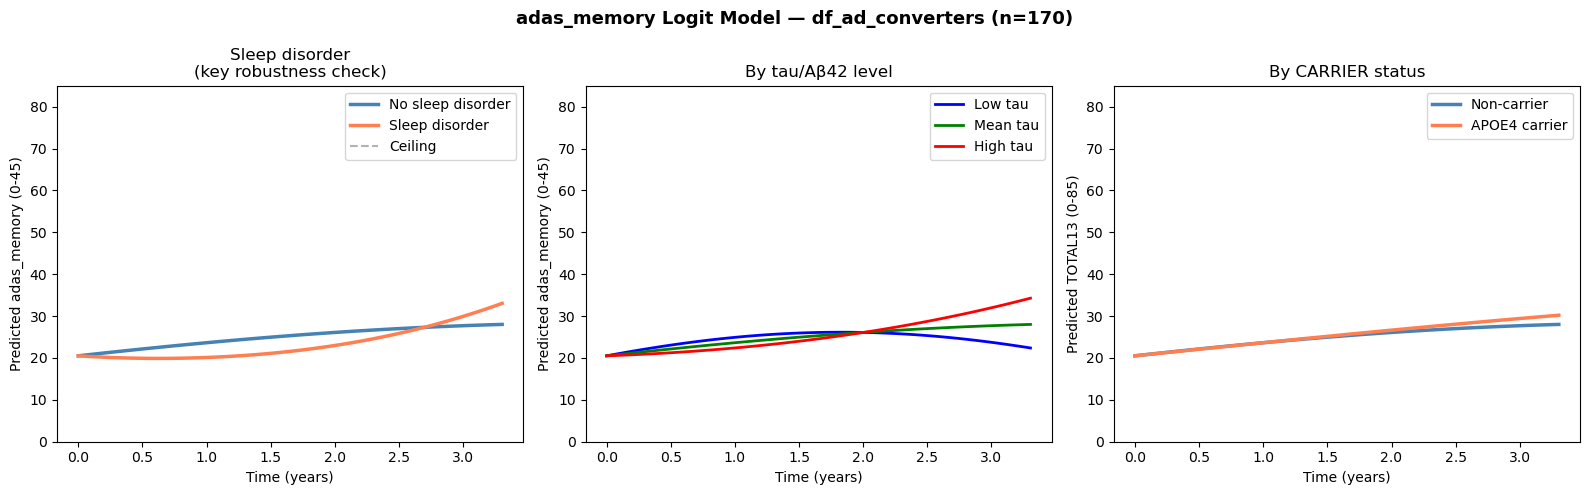


=== Coefficient survival check vs raw TOTAL13 model ===
Term                                  Raw coef   Logit coef        Survives?
---------------------------------------------------------------------------
time_sq                                  0.240      -0.0260   ❌ flipped
time_sq:CARRIER[T.True]                 -0.088       0.0150   ❌ flipped
PTGENDER                                 0.455      -0.0114   ❌ flipped
time_years:PTGENDER                     -0.211       0.0178   ❌ flipped
time_years:PT_AB_std                     0.785      -0.1480   ❌ flipped
time_years:edu_c                        -0.049      -0.0131   ✅ robust
time_sq:edu_c                            0.011       0.0030   ⚠️ same dir, ns
time_sq:age_c                           -0.024       0.0001   ❌ flipped
time_years:Sleep                         0.505      -0.3456   ❌ flipped
time_sq:Sleep                           -0.053       0.1282   ❌ flipped

=== Sleep effect at mean TOTAL13=31.9 ===
  time_years:Sleep    

In [196]:
MAX_SCORE = 45
eps = 0.5

# ── 1. Distribution diagnostics ───────────────────────────────────────────
print("=== adas_memory Distribution (df_ad_converters) ===")
print(f"N patients: {df_ad_converters['RID'].nunique()}")
print(f"N rows:     {len(df_ad_converters)}")
print(df_ad_converters['adas_memory'].describe())

floor_pct      = 100*(df_ad_converters['adas_memory'] == 0).mean()
ceiling_pct    = 100*(df_ad_converters['adas_memory'] == 45).mean()
near_floor_pct = 100*(df_ad_converters['adas_memory'] <= 5).mean()
near_ceil_pct  = 100*(df_ad_converters['adas_memory'] >= 35).mean()

print(f"\nAt floor   (=0):   {floor_pct:.1f}%")
print(f"At ceiling (=45):  {ceiling_pct:.1f}%")
print(f"Near floor (≤5):   {near_floor_pct:.1f}%")
print(f"Near ceiling (≥35):{near_ceil_pct:.1f}%")

# ── 2. Apply logit transform ───────────────────────────────────────────────
df_ad_converters = df_ad_converters.copy()
df_ad_converters['adas_memory_clipped'] = df_ad_converters['adas_memory'].clip(eps, MAX_SCORE - eps)
df_ad_converters['adas_memory_logit'] = np.log(
    df_ad_converters['adas_memory_clipped'] / (MAX_SCORE - df_ad_converters['adas_memory_clipped'])
)

# ── 3. Run logit model ─────────────────────────────────────────────────────
formula_logit = """
    adas_memory_logit ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_sq:CARRIER
    + time_years:PT_AB_std
    + time_sq:PT_AB_std
    + time_years:age_c
    + time_sq:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:edu_c
    + time_years:Sleep
    + time_sq:Sleep
    + time_years:UTI
    + time_sq:UTI
    + time_years:CM
    + time_sq:CM
    """

model_logit = smf.mixedlm(
    formula_logit,
    data=df_ad_converters,
    groups='RID',
    re_formula='~time_years'
).fit(reml=False)

results_logit = pd.DataFrame({
    'coef': model_logit.fe_params,
    'pval': model_logit.pvalues
})
sig_logit = results_logit[results_logit['pval'] < 0.05].round(6)
print("\n=== Significant predictors (logit adas_memory, df_ad_converters) ===")
print(sig_logit)
print(f"\nBIC logit model: {model_logit.bic:.2f}")

# ── 4. Back-transform helper ───────────────────────────────────────────────
def logit_to_score(logit_val, max_score=85):
    return max_score * np.exp(logit_val) / (1 + np.exp(logit_val))

coefs = dict(model_logit.fe_params)
time_range = np.linspace(0, df_ad_converters['time_years'].max(), 100)

# ── 5. Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'adas_memory Logit Model — df_ad_converters '
             f'(n={df_ad_converters["RID"].nunique()})',
             fontsize=13, fontweight='bold')

# — Sleep trajectories — the key check —
for sleep, label, color in [(0, 'No sleep disorder', 'steelblue'),
                             (1, 'Sleep disorder',    'coral')]:
    logit_pred = (
        coefs.get('Intercept', 0) +
        coefs.get('time_years', 0) * time_range +
        coefs.get('time_sq', 0) * time_range**2 +
        coefs.get('time_years:Sleep', 0) * time_range * sleep +
        coefs.get('time_sq:Sleep', 0) * time_range**2 * sleep
    )
    axes[0].plot(time_range, logit_to_score(logit_pred),
                 label=label, color=color, linewidth=2.5)
axes[0].set_ylim(0, 85)
axes[0].axhline(85, color='black', linestyle='--', alpha=0.3, label='Ceiling')
axes[0].set_xlabel('Time (years)'); axes[0].set_ylabel('Predicted adas_memory (0-45)')
axes[0].set_title('Sleep disorder\n(key robustness check)')
axes[0].legend()

# — Tau trajectories —
for tau_val, label, color in [(-1, 'Low tau',  'blue'),
                                (0,  'Mean tau', 'green'),
                                (1,  'High tau', 'red')]:
    logit_pred = (
        coefs.get('Intercept', 0) +
        coefs.get('time_years', 0) * time_range +
        coefs.get('time_sq', 0) * time_range**2 +
        coefs.get('time_years:PT_AB_std', 0) * time_range * tau_val +
        coefs.get('time_sq:PT_AB_std', 0) * time_range**2 * tau_val
    )
    axes[1].plot(time_range, logit_to_score(logit_pred),
                 label=label, color=color, linewidth=2)
axes[1].set_ylim(0, 85)
axes[1].axhline(85, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Time (years)'); axes[1].set_ylabel('Predicted adas_memory (0-45)')
axes[1].set_title('By tau/Aβ42 level')
axes[1].legend()

# — CARRIER trajectories —
for carrier, label, color in [(False, 'Non-carrier',   'steelblue'),
                               (True,  'APOE4 carrier', 'coral')]:
    logit_pred = (
        coefs.get('Intercept', 0) +
        coefs.get('time_years', 0) * time_range +
        coefs.get('time_sq', 0) * time_range**2 +
        coefs.get('time_years:CARRIER[T.True]', 0) * time_range * carrier +
        coefs.get('time_sq:CARRIER[T.True]', 0) * time_range**2 * carrier
    )
    axes[2].plot(time_range, logit_to_score(logit_pred),
                 label=label, color=color, linewidth=2.5)
axes[2].set_ylim(0, 85)
axes[2].axhline(85, color='black', linestyle='--', alpha=0.3)
axes[2].set_xlabel('Time (years)'); axes[2].set_ylabel('Predicted TOTAL13 (0-85)')
axes[2].set_title('By CARRIER status')
axes[2].legend()

plt.tight_layout()
plt.savefig('TOTAL13_logit_trajectories_ad_converters.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Coefficient survival check vs raw TOTAL13 model ────────────────────
print("\n=== Coefficient survival check vs raw TOTAL13 model ===")
print(f"{'Term':<35} {'Raw coef':>10} {'Logit coef':>12} {'Survives?':>16}")
print("-" * 75)

raw_coefs = {
    'time_sq':                    0.240,
    'time_sq:CARRIER[T.True]':   -0.088,
    'PTGENDER':                   0.455,
    'time_years:PTGENDER':       -0.211,
    'time_years:PT_AB_std':       0.785,
    'time_years:edu_c':          -0.049,
    'time_sq:edu_c':              0.011,
    'time_sq:age_c':             -0.024,
    'time_years:Sleep':           0.505,
    'time_sq:Sleep':             -0.053,
}

for term, raw_val in raw_coefs.items():
    logit_val = coefs.get(term, np.nan)
    is_sig    = term in sig_logit.index
    same_dir  = np.sign(raw_val) == np.sign(logit_val) if not np.isnan(logit_val) else False
    status    = ('✅ robust'        if same_dir and is_sig  else
                 '⚠️ same dir, ns' if same_dir and not is_sig else
                 '❌ flipped')
    print(f"{term:<35} {raw_val:>10.3f} {logit_val:>12.4f}   {status}")

# ── 7. Sleep effect size in TOTAL13 points at mean ────────────────────────
mean_logit = df_ad_converters['adas_memory_logit'].mean()
mean_score = logit_to_score(mean_logit)
p = np.exp(mean_logit) / (1 + np.exp(mean_logit))

print(f"\n=== Sleep effect at mean TOTAL13={mean_score:.1f} ===")
for term in ['time_years:Sleep', 'time_sq:Sleep']:
    val = coefs.get(term, np.nan)
    if not np.isnan(val):
        pts = val * MAX_SCORE * p * (1 - p)
        raw = raw_coefs.get(term, np.nan)
        attenuation = (1 - abs(pts) / abs(raw)) * 100 if not np.isnan(raw) else np.nan
        print(f"  {term:<30}: {val:+.4f} logit ≈ {pts:+.3f} TOTAL13 pts "
              f"(raw={raw:+.3f}, attenuation={attenuation:.1f}%)")

=== adas_memory Distribution (df_ad_converters) ===
N patients: 170
N rows:     2076
count    2076.000000
mean        0.774566
std         1.554240
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        14.000000
Name: adas_language, dtype: float64

At floor   (=0):   64.5%
At ceiling (=20):  0.0%
Near floor (≤5):   97.4%
Near ceiling (≥15):0.0%

=== Significant predictors (logit adas_language, df_ad_converters) ===
                          coef      pval
Intercept            -3.332416  0.000000
RID Var                    NaN  0.000000
age_c                 0.018658  0.031049
baseline_c            0.050012  0.000000
time_sq               0.090497  0.000000
time_sq:PT_AB_std    -0.066474  0.000002
time_sq:Sleep         0.133659  0.000016
time_sq:UTI          -0.050450  0.034146
time_sq:baseline_c    0.003077  0.037906
time_sq:edu_c         0.010609  0.000002
time_years           -0.236415  0.022458
time_years Var             NaN  0.000000
time_ye

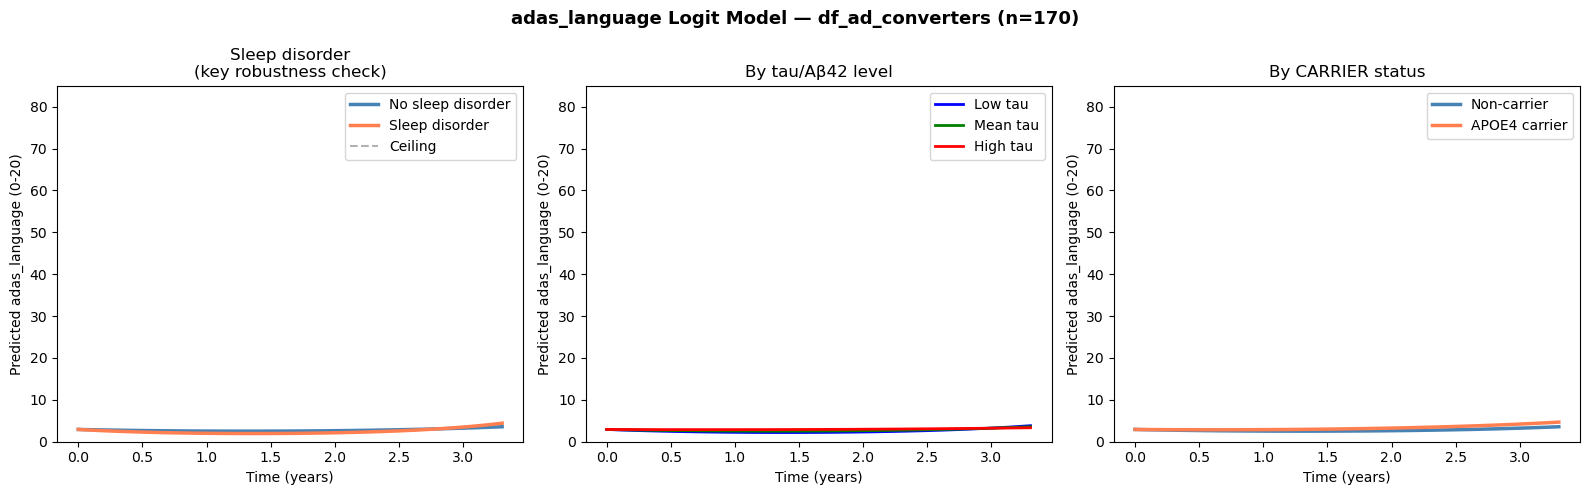


=== Coefficient survival check vs raw TOTAL13 model ===
Term                                  Raw coef   Logit coef        Survives?
---------------------------------------------------------------------------
time_sq                                  0.240       0.0905   ✅ robust
time_sq:CARRIER[T.True]                 -0.088      -0.0189   ⚠️ same dir, ns
PTGENDER                                 0.455      -0.0253   ❌ flipped
time_years:PTGENDER                     -0.211       0.0287   ❌ flipped
time_years:PT_AB_std                     0.785       0.1977   ✅ robust
time_years:edu_c                        -0.049      -0.0338   ✅ robust
time_sq:edu_c                            0.011       0.0106   ✅ robust
time_sq:age_c                           -0.024       0.0031   ❌ flipped
time_years:Sleep                         0.505      -0.3744   ❌ flipped
time_sq:Sleep                           -0.053       0.1337   ❌ flipped

=== Sleep effect at mean TOTAL13=3.3 ===
  time_years:Sleep        

In [197]:
MAX_SCORE = 20
eps = 0.5

# ── 1. Distribution diagnostics ───────────────────────────────────────────
print("=== adas_memory Distribution (df_ad_converters) ===")
print(f"N patients: {df_ad_converters['RID'].nunique()}")
print(f"N rows:     {len(df_ad_converters)}")
print(df_ad_converters['adas_language'].describe())

floor_pct      = 100*(df_ad_converters['adas_language'] == 0).mean()
ceiling_pct    = 100*(df_ad_converters['adas_language'] == 20).mean()
near_floor_pct = 100*(df_ad_converters['adas_language'] <= 5).mean()
near_ceil_pct  = 100*(df_ad_converters['adas_language'] >= 15).mean()

print(f"\nAt floor   (=0):   {floor_pct:.1f}%")
print(f"At ceiling (=20):  {ceiling_pct:.1f}%")
print(f"Near floor (≤5):   {near_floor_pct:.1f}%")
print(f"Near ceiling (≥15):{near_ceil_pct:.1f}%")

# ── 2. Apply logit transform ───────────────────────────────────────────────
df_ad_converters = df_ad_converters.copy()
df_ad_converters['adas_language_clipped'] = df_ad_converters['adas_language'].clip(eps, MAX_SCORE - eps)
df_ad_converters['adas_language_logit'] = np.log(
    df_ad_converters['adas_language_clipped'] / (MAX_SCORE - df_ad_converters['adas_language_clipped'])
)

# ── 3. Run logit model ─────────────────────────────────────────────────────
formula_logit = """
    adas_language_logit ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_sq:CARRIER
    + time_years:PT_AB_std
    + time_sq:PT_AB_std
    + time_years:age_c
    + time_sq:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:edu_c
    + time_years:Sleep
    + time_sq:Sleep
    + time_years:UTI
    + time_sq:UTI
    + time_years:CM
    + time_sq:CM
    """

model_logit = smf.mixedlm(
    formula_logit,
    data=df_ad_converters,
    groups='RID',
    re_formula='~time_years'
).fit(reml=False)

results_logit = pd.DataFrame({
    'coef': model_logit.fe_params,
    'pval': model_logit.pvalues
})
sig_logit = results_logit[results_logit['pval'] < 0.05].round(6)
print("\n=== Significant predictors (logit adas_language, df_ad_converters) ===")
print(sig_logit)
print(f"\nBIC logit model: {model_logit.bic:.2f}")

# ── 4. Back-transform helper ───────────────────────────────────────────────
def logit_to_score(logit_val, max_score=85):
    return max_score * np.exp(logit_val) / (1 + np.exp(logit_val))

coefs = dict(model_logit.fe_params)
time_range = np.linspace(0, df_ad_converters['time_years'].max(), 100)

# ── 5. Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'adas_language Logit Model — df_ad_converters '
             f'(n={df_ad_converters["RID"].nunique()})',
             fontsize=13, fontweight='bold')

# — Sleep trajectories — the key check —
for sleep, label, color in [(0, 'No sleep disorder', 'steelblue'),
                             (1, 'Sleep disorder',    'coral')]:
    logit_pred = (
        coefs.get('Intercept', 0) +
        coefs.get('time_years', 0) * time_range +
        coefs.get('time_sq', 0) * time_range**2 +
        coefs.get('time_years:Sleep', 0) * time_range * sleep +
        coefs.get('time_sq:Sleep', 0) * time_range**2 * sleep
    )
    axes[0].plot(time_range, logit_to_score(logit_pred),
                 label=label, color=color, linewidth=2.5)
axes[0].set_ylim(0, 85)
axes[0].axhline(85, color='black', linestyle='--', alpha=0.3, label='Ceiling')
axes[0].set_xlabel('Time (years)'); axes[0].set_ylabel('Predicted adas_language (0-20)')
axes[0].set_title('Sleep disorder\n(key robustness check)')
axes[0].legend()

# — Tau trajectories —
for tau_val, label, color in [(-1, 'Low tau',  'blue'),
                                (0,  'Mean tau', 'green'),
                                (1,  'High tau', 'red')]:
    logit_pred = (
        coefs.get('Intercept', 0) +
        coefs.get('time_years', 0) * time_range +
        coefs.get('time_sq', 0) * time_range**2 +
        coefs.get('time_years:PT_AB_std', 0) * time_range * tau_val +
        coefs.get('time_sq:PT_AB_std', 0) * time_range**2 * tau_val
    )
    axes[1].plot(time_range, logit_to_score(logit_pred),
                 label=label, color=color, linewidth=2)
axes[1].set_ylim(0, 85)
axes[1].axhline(85, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Time (years)'); axes[1].set_ylabel('Predicted adas_language (0-20)')
axes[1].set_title('By tau/Aβ42 level')
axes[1].legend()

# — CARRIER trajectories —
for carrier, label, color in [(False, 'Non-carrier',   'steelblue'),
                               (True,  'APOE4 carrier', 'coral')]:
    logit_pred = (
        coefs.get('Intercept', 0) +
        coefs.get('time_years', 0) * time_range +
        coefs.get('time_sq', 0) * time_range**2 +
        coefs.get('time_years:CARRIER[T.True]', 0) * time_range * carrier +
        coefs.get('time_sq:CARRIER[T.True]', 0) * time_range**2 * carrier
    )
    axes[2].plot(time_range, logit_to_score(logit_pred),
                 label=label, color=color, linewidth=2.5)
axes[2].set_ylim(0, 85)
axes[2].axhline(85, color='black', linestyle='--', alpha=0.3)
axes[2].set_xlabel('Time (years)'); axes[2].set_ylabel('Predicted adas_language (0-20)')
axes[2].set_title('By CARRIER status')
axes[2].legend()

plt.tight_layout()
plt.savefig('TOTAL13_logit_trajectories_ad_converters.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Coefficient survival check vs raw TOTAL13 model ────────────────────
print("\n=== Coefficient survival check vs raw TOTAL13 model ===")
print(f"{'Term':<35} {'Raw coef':>10} {'Logit coef':>12} {'Survives?':>16}")
print("-" * 75)

raw_coefs = {
    'time_sq':                    0.240,
    'time_sq:CARRIER[T.True]':   -0.088,
    'PTGENDER':                   0.455,
    'time_years:PTGENDER':       -0.211,
    'time_years:PT_AB_std':       0.785,
    'time_years:edu_c':          -0.049,
    'time_sq:edu_c':              0.011,
    'time_sq:age_c':             -0.024,
    'time_years:Sleep':           0.505,
    'time_sq:Sleep':             -0.053,
}

for term, raw_val in raw_coefs.items():
    logit_val = coefs.get(term, np.nan)
    is_sig    = term in sig_logit.index
    same_dir  = np.sign(raw_val) == np.sign(logit_val) if not np.isnan(logit_val) else False
    status    = ('✅ robust'        if same_dir and is_sig  else
                 '⚠️ same dir, ns' if same_dir and not is_sig else
                 '❌ flipped')
    print(f"{term:<35} {raw_val:>10.3f} {logit_val:>12.4f}   {status}")

# ── 7. Sleep effect size in TOTAL13 points at mean ────────────────────────
mean_logit = df_ad_converters['adas_language_logit'].mean()
mean_score = logit_to_score(mean_logit)
p = np.exp(mean_logit) / (1 + np.exp(mean_logit))

print(f"\n=== Sleep effect at mean TOTAL13={mean_score:.1f} ===")
for term in ['time_years:Sleep', 'time_sq:Sleep']:
    val = coefs.get(term, np.nan)
    if not np.isnan(val):
        pts = val * MAX_SCORE * p * (1 - p)
        raw = raw_coefs.get(term, np.nan)
        attenuation = (1 - abs(pts) / abs(raw)) * 100 if not np.isnan(raw) else np.nan
        print(f"  {term:<30}: {val:+.4f} logit ≈ {pts:+.3f} TOTAL13 pts "
              f"(raw={raw:+.3f}, attenuation={attenuation:.1f}%)")

### Logitudinal PET results:

In [300]:
amyloid = pd.read_csv('data/UCBERKELEY_AMY_6MM_13Mar2026.csv')  
tau = pd.read_csv('data/UCBERKELEY_TAU_6MM_13Mar2026.csv')  
amyloid['VISCODE'].value_counts()
print(amyloid.columns  )

Index(['LONIUID', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'SCANDATE', 'SITEID',
       'PROCESSDATE', 'IMAGE_RESOLUTION', 'qc_flag',
       ...
       'RIGHT_PALLIDUM_VOLUME', 'RIGHT_PUTAMEN_SUVR', 'RIGHT_PUTAMEN_VOLUME',
       'RIGHT_THALAMUS_PROPER_SUVR', 'RIGHT_THALAMUS_PROPER_VOLUME',
       'RIGHT_VENTRALDC_SUVR', 'RIGHT_VENTRALDC_VOLUME', 'RIGHT_VESSEL_SUVR',
       'RIGHT_VESSEL_VOLUME', 'update_stamp'],
      dtype='object', length=344)


In [301]:
amyloid_converters = df_ad_converters.merge(
    amyloid[['RID', 'VISCODE', 'SUMMARY_SUVR']],
    left_on=['RID', 'VISCODE'],
    right_on=['RID', 'VISCODE'],    
    how='left')
amyloid_converters.rename(columns={'SUMMARY_SUVR': 'amyloid_SUVR'}, inplace=True)
amyloid_converters.dropna(subset=['amyloid_SUVR'], inplace=True)
print(f"ADAS-Cog converters with amyloid data: {amyloid_converters['RID'].nunique()} patients, {len(amyloid_converters)}  rows")

ADAS-Cog converters with amyloid data: 244 patients, 492  rows


In [302]:
print(df_ad_converters.head())

   TOTAL13  TOTAL13_AD_start VISCODE     VISDATE  PHASE  days_since_entry  \
0    47.00             26.00     m12  2008-05-12  ADNI1             354.0   
1    26.00             26.00      bl  2007-05-24  ADNI1               0.0   
2    47.00             29.67     m18  2008-12-01  ADNI1             564.0   
3    45.67             29.67     m12  2008-05-29  ADNI1             378.0   
4    47.33             29.67     m06  2007-11-15  ADNI1             182.0   

   age_at_baseline  PTGENDER  CARRIER   HOMO  ...  ABETA42    TAU   PTAU  \
0        69.475702       1.0    False  False  ...    392.5  575.0  64.37   
1        69.475702       1.0    False  False  ...    392.5  575.0  64.37   
2        77.705681       2.0     True  False  ...    689.2  232.5  17.01   
3        77.705681       2.0     True  False  ...    689.2  232.5  17.01   
4        77.705681       2.0     True  False  ...    689.2  232.5  17.01   

   PTAU_ABETA42  PT_AB_std    CSF_date   time_sq  baseline_c  first_dx  \
0     

In [303]:
print(amyloid_converters[['RID', 'VISCODE', 'amyloid_SUVR']].head())

      RID VISCODE  amyloid_SUVR
867   376     m48         0.888
868   292     m48         0.958
869   729     m48         1.446
870   626     m48         1.407
871  2047      bl         1.748


In [304]:
print(df_ad_converters.groupby(['RID','VISCODE']).size().sort_values(ascending=False).head())
print(amyloid.groupby(['RID','VISCODE']).size().sort_values(ascending=False).head())

RID   VISCODE
3     bl         1
4293  v03        1
4262  v03        1
4258  v21        1
      v11        1
dtype: int64
RID   VISCODE
5157  init       2
6830  bl         2
4278  y2         2
6757  bl         2
6643  y2         2
dtype: int64


In [305]:
tau_converters = df_ad_converters.merge(
    tau[['RID', 'VISCODE', 'META_TEMPORAL_SUVR']],
    left_on=['RID', 'VISCODE'],
    right_on=['RID', 'VISCODE'],    
    how='inner')
tau_converters.rename(columns={'META_TEMPORAL_SUVR': 'tau_SUVR'}, inplace=True)
print(f"ADAS-Cog converters with tau data: {tau_converters['RID'].nunique()} patients, {len(tau_converters)} rows")

ADAS-Cog converters with tau data: 43 patients, 84 rows


In [307]:
baseline_amyloid = (amyloid_converters[amyloid_converters['time_years'] == 0][['RID', 'amyloid_SUVR']].drop_duplicates(subset='RID')
)
amyloid_converters_new = amyloid_converters.merge(baseline_amyloid, on='RID', suffixes=('', '_baseline'))
print(amyloid_converters_new[['RID', 'amyloid_SUVR', 'amyloid_SUVR_baseline', 'time_years']].head(20))


     RID  amyloid_SUVR  amyloid_SUVR_baseline  time_years
0   2047         1.748                  1.748         0.0
1   2106         1.443                  1.443         0.0
2   2087         1.249                  1.249         0.0
3   2213         1.324                  1.324         0.0
4   2195         1.581                  1.581         0.0
5   2155         1.284                  1.284         0.0
6   2185         1.028                  1.028         0.0
7   2248         1.609                  1.609         0.0
8   2220         0.925                  0.925         0.0
9   2216         1.323                  1.323         0.0
10  2316         1.515                  1.515         0.0
11  2373         1.261                  1.261         0.0
12  2381         1.356                  1.356         0.0
13  2391         1.739                  1.739         0.0
14  2398         1.110                  1.110         0.0
15  2380         1.345                  1.345         0.0
16  2403      